In [1]:
library(readr)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(cowplot)

fp_abinitio = "collected_caprievals/all_caprievals_unrestrained_10k.tsv"
fp_oracle = "collected_caprievals/all_caprievals_oracle_100_10.tsv" 
fp_eval = "collected_caprievals/all_caprievals_eval_here.tsv"
complexes = dir("data/haddock_units")
complexes



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "1JK9" "1KXP" "1US7" "1Z5Y" "1ZHH" "1ZHI" "2A5T" "2AJF" "2C0L" "2GAF"
[11] "2YVJ" "3PC8" "4H03"

In [2]:
erase = function(patt, x){gsub(patt, "", x)}

if(!file.exists(fp_abinitio)){
    capri_unrestr_fps = file.path("data/haddock_units", complexes, "haddock_unrestr_10k/7_caprieval/capri_ss.tsv")
    capri_unrestr_fps = capri_unrestr_fps[file.exists(capri_unrestr_fps)]
    capri_unrestr = do.call(rbind,lapply(capri_unrestr_fps, function(fp){
        #fp = capri_oracle_fps[grepl(xname, capri_oracle_fps)]
        xname = erase("^.+/",erase("/+haddock_unrestr_10k/7_caprieval/capri_ss.tsv", fp))
        data = read_tsv(fp, show_col_types=FALSE)%>%
            mutate(complex=xname, run="oracle")%>%
            arrange(score)
        data$score_rank = 1:nrow(data)
        return(data)
    }))
    write_tsv(capri_unrestr, file="collected_caprievals/all_caprievals_unrestrained_10k.tsv")
}

if(!file.exists(fp_oracle)){
    capri_oracle_fps = file.path("data/haddock_units", complexes, "haddock_oracle_100_10/7_caprieval/capri_ss.tsv")
    capri_oracle_fps = capri_oracle_fps[file.exists(capri_oracle_fps)]
    capri_oracle = do.call(rbind,lapply(capri_oracle_fps, function(fp){
        #fp = capri_oracle_fps[grepl(xname, capri_oracle_fps)]
        xname = erase("^.+/",erase("/+haddock_oracle_100_10/7_caprieval/capri_ss.tsv", fp))
        data = read_tsv(fp, show_col_types=FALSE)%>%
            mutate(complex=xname, run="oracle")%>%
            arrange(score)
        data$score_rank = 1:nrow(data)
        return(data)
    }))
    write_tsv(capri_oracle, file="collected_caprievals/all_caprievals_oracle_100_10.tsv")
}

if(!file.exists(fp_eval)){
    capri_eval_fps = file.path("data/haddock_units", complexes, paste0(complexes, "_result.csv")) 
    capri_eval_fps = capri_eval_fps[file.exists(capri_eval_fps)]
    #capri_eval_fps = dir("from_fra", full.names=TRUE)
    erase = function(patt, x) {gsub(patt,"", x)}
    all_res = do.call(rbind, lapply(capri_eval_fps, function(fp){
    	df = read_csv(fp, show_col_type=FALSE)%>%
    		arrange(score)%>%
    		mutate(score_rank = order(score))%>%
            mutate(complex=erase("^.+/|_result.csv",fp))
    }))
    write_tsv(all_res, file="collected_caprievals/all_caprievals_eval.tsv")    
}

In [3]:
res_oracle = read_tsv(fp_oracle, show_col_types=FALSE)%>%
    mutate(run="oracle")%>%as.data.frame()
#res_oracle = read_tsv("collected_caprievals//all_caprievals_oracle_100_10.tsv.tsv", show_col_types=FALSE)%>%
#    mutate(run="oracle")%>%as.data.frame()
res_abinitio = read_tsv(fp_abinitio, show_col_types=FALSE)%>%
    mutate(run="ab-initio")%>%as.data.frame()
res_eval = read_tsv(fp_eval, show_col_types=FALSE)%>%
    mutate(run="eval")

if(any("system" %in% colnames(res_eval))){
    res_eval = res_eval%>%
        rename(complex="system")
}

head(res_oracle, 2)
head(res_abinitio, 2)
head(res_eval, 2)

,model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rdcs,rg,sym,total,vdw,vean,xpcs,complex,run,score_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,../6_seletopclusts/cluster_1_model_1.pdb,-,1,-74.262,2.817,0.209,3.711,3.084,0.423,3.613,⋯,0,0,0,-271.515,-27.263,0,0,1JK9,oracle,1
2,../6_seletopclusts/cluster_1_model_2.pdb,-,2,-74.014,2.683,0.291,2.683,2.590,0.479,3.356,⋯,0,0,0,-270.185,-29.484,0,0,1JK9,oracle,2


,model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rdcs,rg,sym,total,vdw,vean,xpcs,complex,run,score_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,../6_seletopclusts/cluster_2_model_1.pdb,-,1,-78.169,12.339,0.012,21.641,19.850,0.053,12.891,⋯,0,0,0,-300.753,-16.690,0,0,1JK9,ab-initio,1
2,../6_seletopclusts/cluster_1_model_1.pdb,-,2,-69.342,18.756,0.000,55.654,50.251,0.010,19.633,⋯,0,0,0,-281.389,-26.744,0,0,1JK9,ab-initio,2


model,md5,caprieval_rank,score,irmsd,fnat,lrmsd,ilrmsd,dockq,rmsd,⋯,rg,sym,total,vdw,vean,xpcs,provenance,score_rank,complex,run
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>
../3_emref/emref_1.pdb,-,1,-88.867,10.257,0.023,20.545,18.574,0.063,11.957,⋯,0,0,-255.406,-42.982,0,0,patches_0_1_1,1,1JK9,eval
../3_emref/emref_1.pdb,-,1,-83.067,10.584,0.000,27.557,25.932,0.036,10.232,⋯,0,0,-257.619,-28.392,0,0,patches_1_1_1,2,1JK9,eval


In [4]:
################################################# PLOTTING RESULTS
### 1) RMSD vs IRMSD values
#### MANUAL PERMANENT PALETTE:
### complex_colors = c()
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2GAF','2YVJ','3PC8','4H03')

hex_colors <- c("#70A8CE", "#FFB26E", "#88C588", "#E67D7E", "#BDA3D6", "#BA9993", "#EEADDA")
hex_light2 <- colorRampPalette(c("white", "white"))(7)  # placeholder
hex_light2 <- sapply(hex_colors, function(c) colorRampPalette(c(c, "#FFFFFF"))(3)[2])

permanent_palette = c(hex_colors, hex_light2)
names(permanent_palette) = complexes
permanent_palette = permanent_palette[complexes]
permanent_palette

1JK9      1KXP      1US7      1Z5Y      1ZHH      1ZHI      2A5T      2AJF 
"#70A8CE" "#FFB26E" "#88C588" "#E67D7E" "#BDA3D6" "#BA9993" "#EEADDA" "#B7D3E6" 
     2C0L      2GAF      2YVJ      3PC8      4H03 
"#FFD8B6" "#C3E2C3" "#F2BEBE" "#DED1EA" "#DCCCC9"

In [5]:
# 1. Create a dummy data frame for the legend
dummy_df <- data.frame(
  x = 1:length(complexes),
  y = 1,
  Complex = factor(complexes, levels = complexes) # Maintains your exact vector order
)

# 2. Build a dummy plot with larger text and 2 columns
dummy_plot <- ggplot(dummy_df, aes(x = x, y = y, fill = Complex)) +
  geom_raster() + 
  scale_fill_manual(values = permanent_palette) +
  theme_minimal() +
  theme(
    legend.position = "right",
    legend.direction = "vertical",
    legend.box = "vertical",
    # Increase text size (adjust the numbers/rel values as needed for your final layout)
    legend.title = element_text(size =  rel(1.5), face = "bold"), # Scale up title by 1.5x
    legend.text = element_text(size = rel(1.3)),                 # Scale up keys/labels by 1.3x
    legend.key.size = unit(1.5, "lines")                         # Increases color box size to match larger text
  ) +
  guides(fill = guide_legend(
    title = "Complex",   # Explicitly sets the title
    ncol = 2, 
    byrow = FALSE
  )) 

# 3. Extract and store the legend
manual_complex_legend <- cowplot::get_legend(dummy_plot)

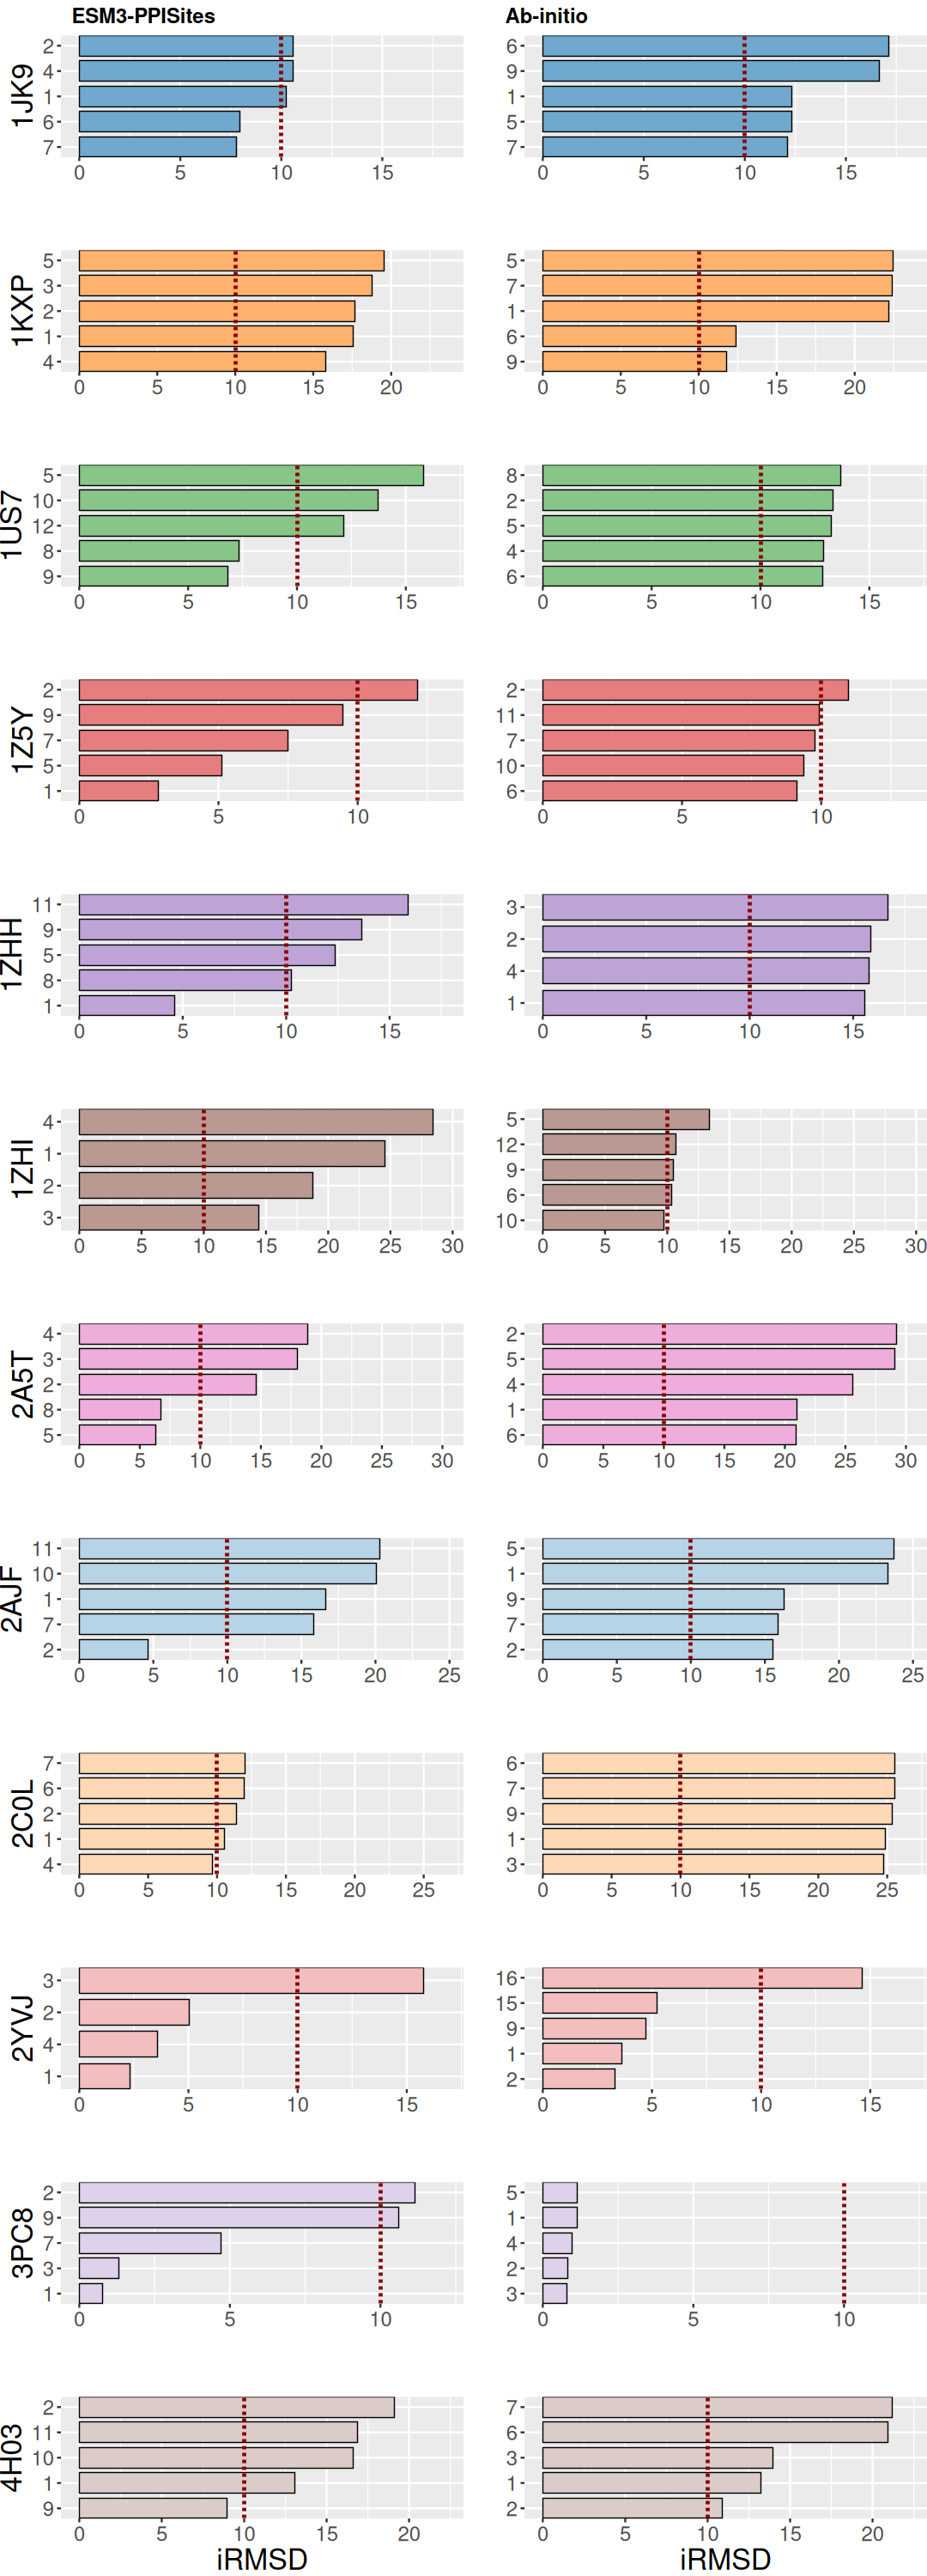

In [6]:
top_n = 5
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
bar_panels = list()
bar_width = 0.8

for(my_complex in complexes){
    
    df = res_abinitio %>%
        filter(complex == my_complex)%>%
        arrange(irmsd)%>%head(top_n)%>% 
        mutate(y = paste0(complex, "_", score_rank))
    p_bars_abinitio = ggplot() +
        geom_col(data=df, color = "black", linewidth = 0.3, width=bar_width, aes(
            y=reorder(as.integer(score_rank), irmsd), x=irmsd, fill=complex)) +
        labs(x="iRMSD", y="")+
        ggtitle(my_complex)
    max_abinitio = max(df$irmsd)
    
    df = res_eval %>%
        filter(complex == my_complex)%>%
        arrange(irmsd)%>%head(top_n)%>% 
        mutate(y = paste0(complex, "_", score_rank))
    max_eval = max(df$irmsd)
    p_bars_eval = ggplot() +
        geom_col(data=df, color = "black", linewidth = 0.3, width=bar_width, aes(
            y=reorder(as.integer(score_rank), irmsd), x=irmsd, fill=complex)) +
        labs(x="iRMSD", y=my_complex) 
    max_both = max(max_abinitio, max_eval)
    
    bplot_list = list(p_bars_eval, p_bars_abinitio)
    bplot_list = lapply(bplot_list, function(myp){
        myp +
            geom_vline(xintercept=10, linetype="dashed", linewidth=1, color="darkred") +
            scale_x_continuous(limits = c(0, max_both+1), breaks = seq(0, 30, by = 5)) +
            scale_y_discrete(expand = expansion(add = c(0.2, 0.2))) +
            scale_fill_manual(values=permanent_palette) +
            theme(legend.position = "none",
                  plot.title = element_text(hjust = 2, size = 20, face = "bold"), 
                  axis.title = element_text(size = 20),       
                  axis.text = element_text(size = 14),                  
                  strip.text = element_text(size = 16))
    })
    bar_panels[[my_complex]] = bplot_list 
}

bar_panels = unlist(bar_panels, recursive = FALSE)

for(i in seq_along(bar_panels)){
 #    if(i == 1){
 #        bar_panels[[i]] = bar_panels[[i]] + ggtitle("ESM3-PPISites")
 #    }
 #    if(i == 2){
 #        bar_panels[[i]] = bar_panels[[i]] + ggtitle("Ab-initio")
 #    }
    if(i %% 2 != 1) {
        bar_panels[[i]] = bar_panels[[i]] + labs(y="")
    }
    if(i < length(bar_panels)-1){
        bar_panels[[i]] = bar_panels[[i]] + labs(x="")
    }
    bar_panels[[i]] = bar_panels[[i]] + 
        theme(plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"))
}

options(repr.plot.height=25, repr.plot.width=9)
plot_grid(plotlist=bar_panels, ncol=2, align = "hv", axis = "tblr", labels=c("ESM3-PPISites", "Ab-initio"))

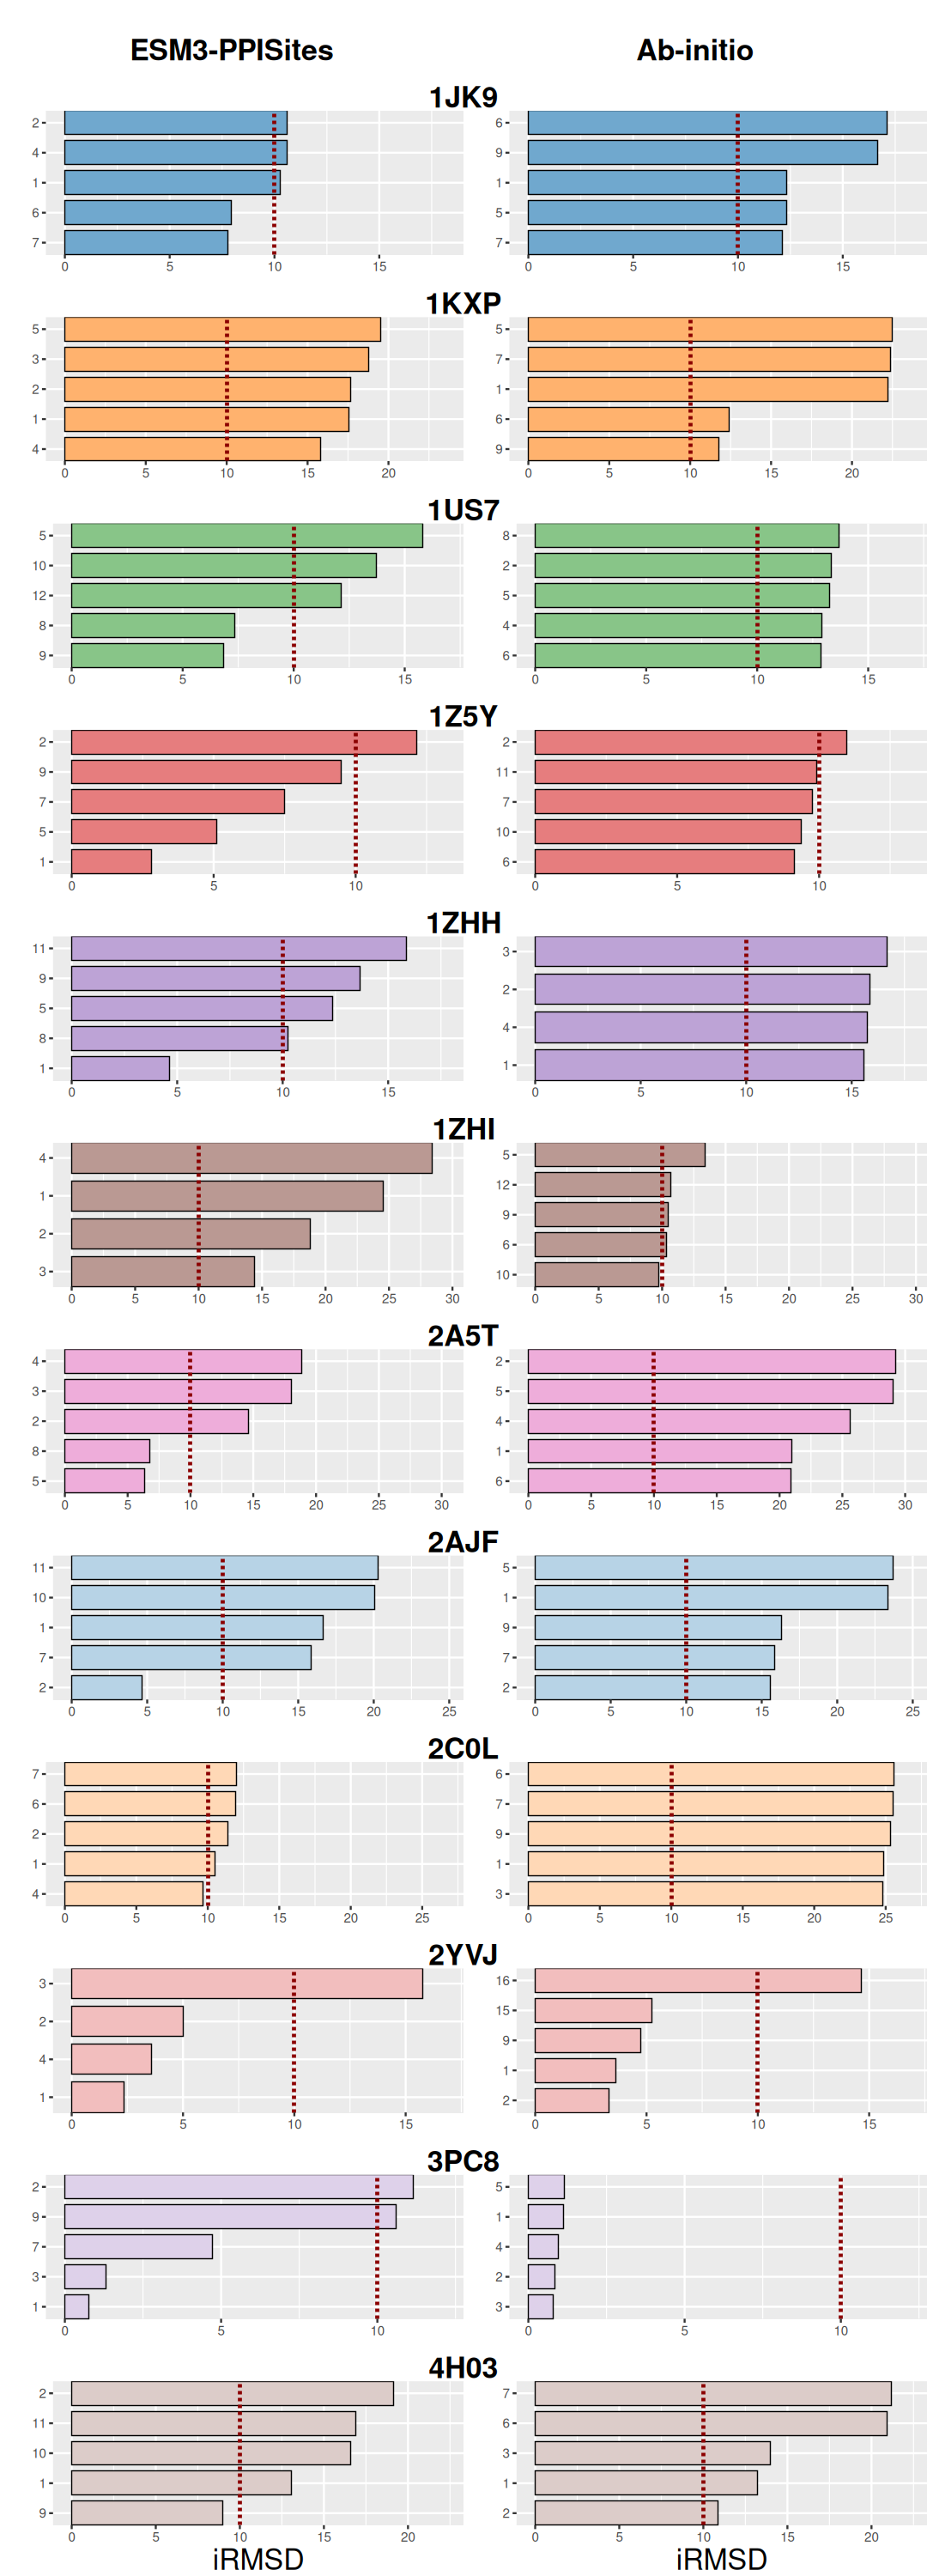

In [7]:
library(cowplot)
library(ggplot2)
library(dplyr)

top_n = 5
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
bar_panels = list()
bar_width = 0.8

for(my_complex in complexes){
    
    df = res_abinitio %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    p_bars_abinitio = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") +
        ggtitle(my_complex)
    max_abinitio = max(df$irmsd)
    
    df = res_eval %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    max_eval = max(df$irmsd)
    p_bars_eval = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") 
    max_both = max(max_abinitio, max_eval)
    
    bplot_list = list(p_bars_eval, p_bars_abinitio)
    bplot_list = lapply(bplot_list, function(myp){
        myp +
            geom_vline(xintercept = 10, linetype = "dashed", linewidth = 1, color = "darkred") +
            scale_x_continuous(limits = c(0, max_both + 1), breaks = seq(0, 30, by = 5)) +
            scale_y_discrete(expand = expansion(add = c(0.2, 0.2))) +
            scale_fill_manual(values = permanent_palette) +
            theme(legend.position = "none",
                  plot.title = element_text(hjust = 2, size = 20, face = "bold"), 
                  axis.title = element_text(size = 20),       
                  axis.text = element_text(size = ),                  
                  strip.text = element_text(size = 16))
    })
    bar_panels[[my_complex]] = bplot_list 
}

bar_panels = unlist(bar_panels, recursive = FALSE)

for(i in seq_along(bar_panels)){
    if(i %% 2 != 1) {
        bar_panels[[i]] = bar_panels[[i]] + labs(y = "")
    }
    if(i < length(bar_panels) - 1){
        bar_panels[[i]] = bar_panels[[i]] + labs(x = "")
    }
    bar_panels[[i]] = bar_panels[[i]] + 
        theme(plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"))
}

# ---- TIGHTER LAYOUT WITH COLUMN HEADERS AND ROW TITLES ----

# Remove individual plot titles since we'll add them as row labels
for(i in seq_along(bar_panels)){
    bar_panels[[i]] = bar_panels[[i]] + ggtitle(NULL)
}

# Build rows: each row is a pair of plots with complex title above
all_rows = list()
for(i in seq_along(complexes)){
    idx1 = 2 * i - 1  # eval plot
    idx2 = 2 * i      # abinitio plot
    
    # Pair of plots side by side, tight
    plot_pair = plot_grid(bar_panels[[idx1]], bar_panels[[idx2]], 
                          ncol = 2, align = "hv", axis = "tblr",
                          rel_widths = c(1, 1))
    
    # Complex name as bold title above the row
    row_title = ggdraw() + 
        draw_label(complexes[i], size = 20, fontface = "bold", x = 0.5, y = 1.2)
    
    all_rows[[i]] = plot_grid(row_title, plot_pair, 
                              ncol = 1, rel_heights = c(0.06, 1),
                              greedy = FALSE)
}

# Column headers as big bold labels
col_header = plot_grid(
    ggdraw() + draw_label("ESM3-PPISites", size = 20, fontface = "bold", x = 0.5, y = 0.5),
    ggdraw() + draw_label("Ab-initio", size = 20, fontface = "bold", x = 0.5, y = 0.5),
    ncol = 2, rel_widths = c(1, 1)
)

# Assemble: column header on top, then all rows
final_plot = plot_grid(col_header, plot_grid(plotlist = all_rows, ncol = 1, greedy = FALSE),
                       ncol = 1, rel_heights = c(0.04, 1), greedy = FALSE)

options(repr.plot.height = 25, repr.plot.width = 9)
print(final_plot)
ggsave(final_plot, file="PPI_plots/ESM3-PPISites_vs_Ab-initio.png", height=25, width=9)


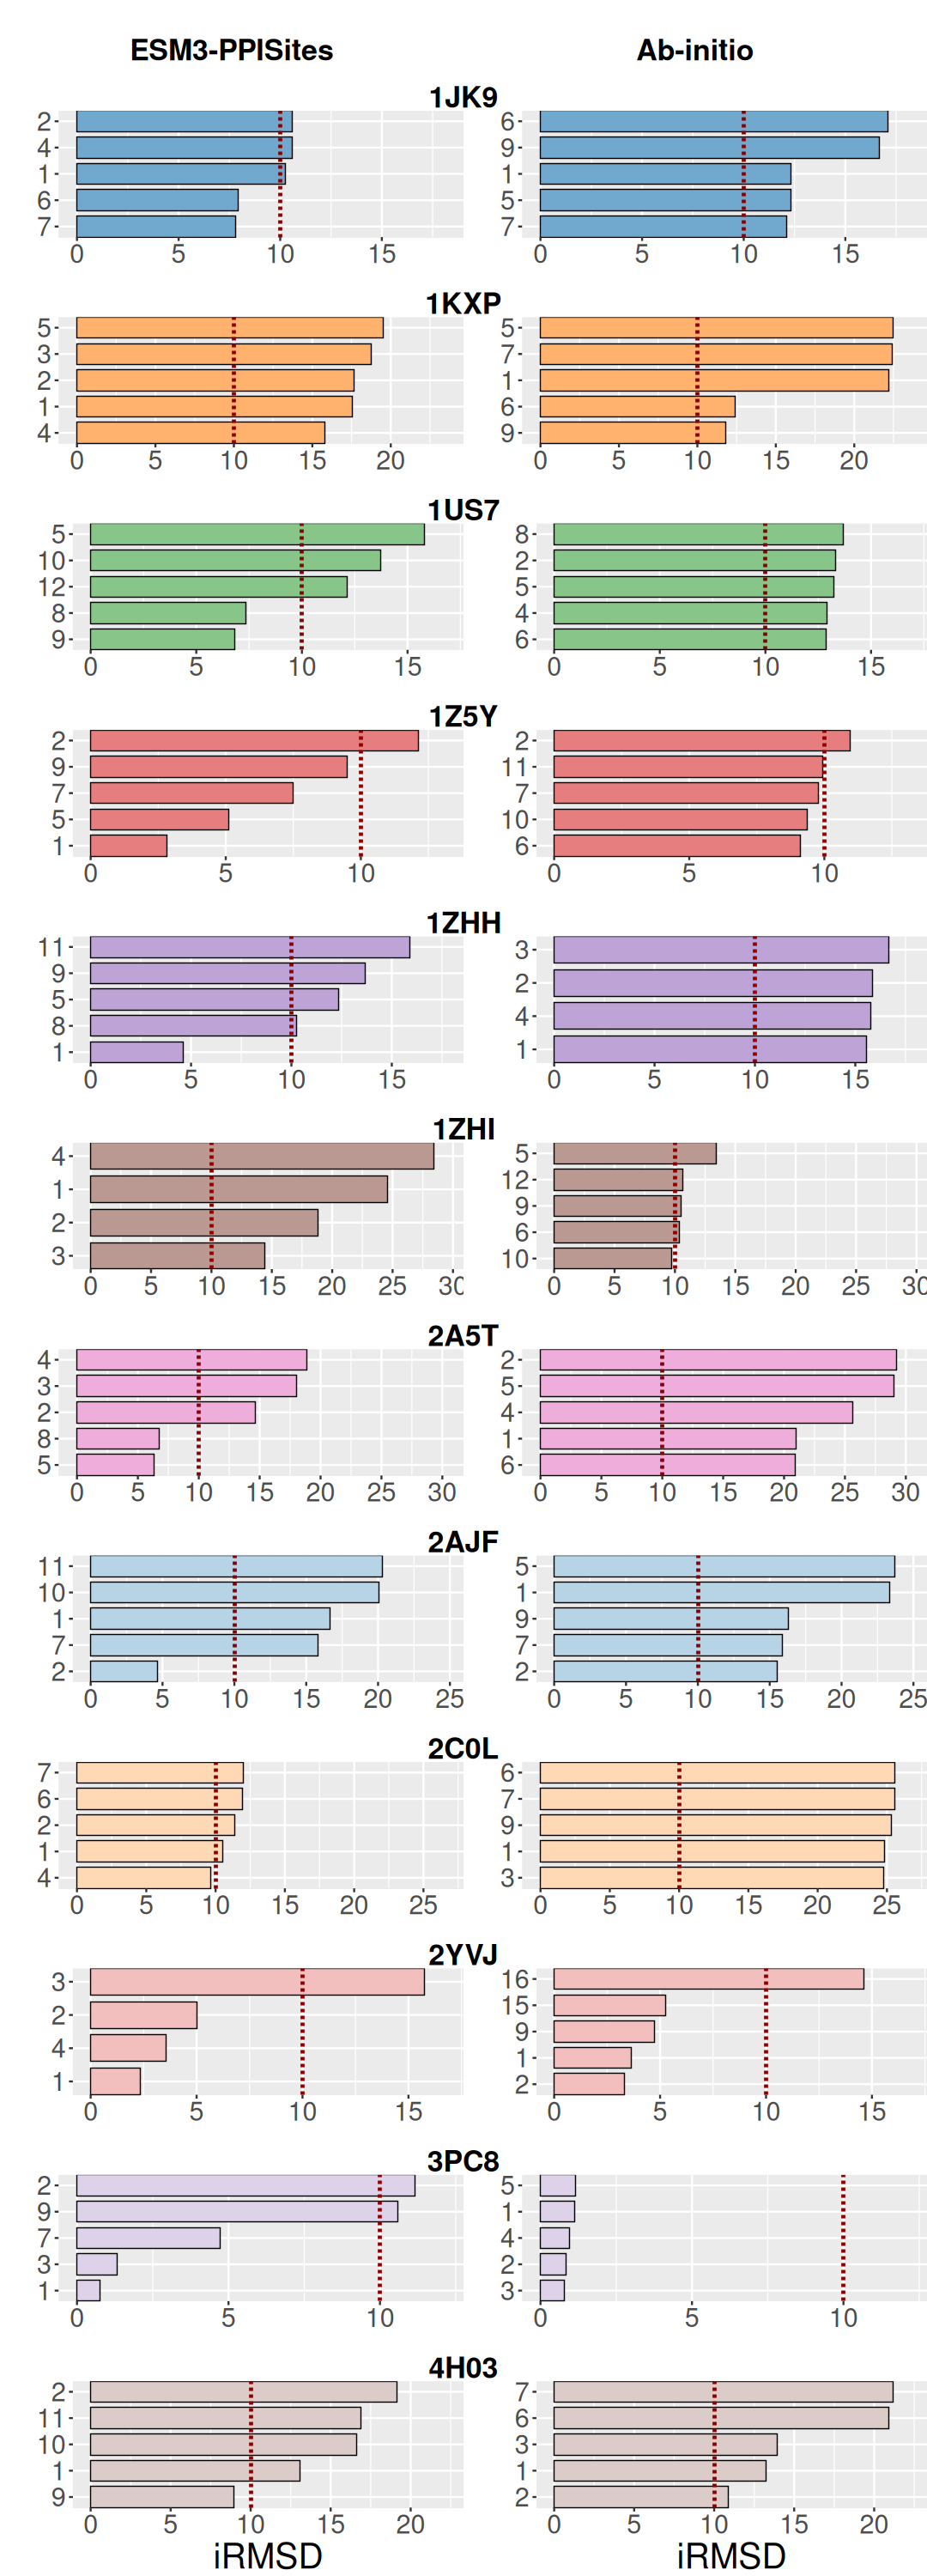

In [8]:
library(cowplot)
library(ggplot2)
library(dplyr)

top_n = 5
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
bar_panels = list()
bar_width = 0.8

for(my_complex in complexes){
    
    df = res_abinitio %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    p_bars_abinitio = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") +
        ggtitle(my_complex)
    max_abinitio = max(df$irmsd)
    
    df = res_eval %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    max_eval = max(df$irmsd)
    p_bars_eval = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") 
    max_both = max(max_abinitio, max_eval)
    
    bplot_list = list(p_bars_eval, p_bars_abinitio)
    bplot_list = lapply(bplot_list, function(myp){
        myp +
            geom_vline(xintercept = 10, linetype = "dashed", linewidth = 1, color = "darkred") +
            scale_x_continuous(limits = c(0, max_both + 1), breaks = seq(0, 30, by = 5)) +
            scale_y_discrete(expand = expansion(add = c(0.2, 0.2))) +
            scale_fill_manual(values = permanent_palette) +
            theme(legend.position = "none",
                  plot.title = element_text(hjust = 2, size = 20, face = "bold"), 
                  axis.title = element_text(size = 24),           # BIGGER axis titles
                  axis.text = element_text(size = 18),              # BIGGER axis text (was empty!)
                  strip.text = element_text(size = 16))
    })
    bar_panels[[my_complex]] = bplot_list 
}

bar_panels = unlist(bar_panels, recursive = FALSE)

for(i in seq_along(bar_panels)){
    if(i %% 2 != 1) {
        bar_panels[[i]] = bar_panels[[i]] + labs(y = "")
    }
    if(i < length(bar_panels) - 1){
        bar_panels[[i]] = bar_panels[[i]] + labs(x = "")
    }
    bar_panels[[i]] = bar_panels[[i]] + 
        theme(plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"))
}

# ---- TIGHTER LAYOUT WITH COLUMN HEADERS AND ROW TITLES ----

# Remove individual plot titles since we'll add them as row labels
for(i in seq_along(bar_panels)){
    bar_panels[[i]] = bar_panels[[i]] + ggtitle(NULL)
}

# Build rows: each row is a pair of plots with complex title above
all_rows = list()
for(i in seq_along(complexes)){
    idx1 = 2 * i - 1  # eval plot
    idx2 = 2 * i      # abinitio plot
    
    # Pair of plots side by side, tight
    plot_pair = plot_grid(bar_panels[[idx1]], bar_panels[[idx2]], 
                          ncol = 2, align = "hv", axis = "tblr",
                          rel_widths = c(1, 1))
    
    # Complex name as bold title above the row
    row_title = ggdraw() + 
        draw_label(complexes[i], size = 20, fontface = "bold", x = 0.5, y = 1.2)
    
    all_rows[[i]] = plot_grid(row_title, plot_pair, 
                              ncol = 1, rel_heights = c(0.06, 1),
                              greedy = FALSE)
}

# Column headers as big bold labels
col_header = plot_grid(
    ggdraw() + draw_label("ESM3-PPISites", size = 20, fontface = "bold", x = 0.5, y = 0.5),
    ggdraw() + draw_label("Ab-initio", size = 20, fontface = "bold", x = 0.5, y = 0.5),
    ncol = 2, rel_widths = c(1, 1)
)

# Assemble: column header on top, then all rows
final_plot = plot_grid(col_header, plot_grid(plotlist = all_rows, ncol = 1, greedy = FALSE),
                       ncol = 1, rel_heights = c(0.04, 1), greedy = FALSE)

options(repr.plot.height = 25, repr.plot.width = 9)
print(final_plot)
ggsave(final_plot, file="PPI_plots/ESM3-PPISites_vs_Ab-initio_bigtext.png", height=25, width=9)

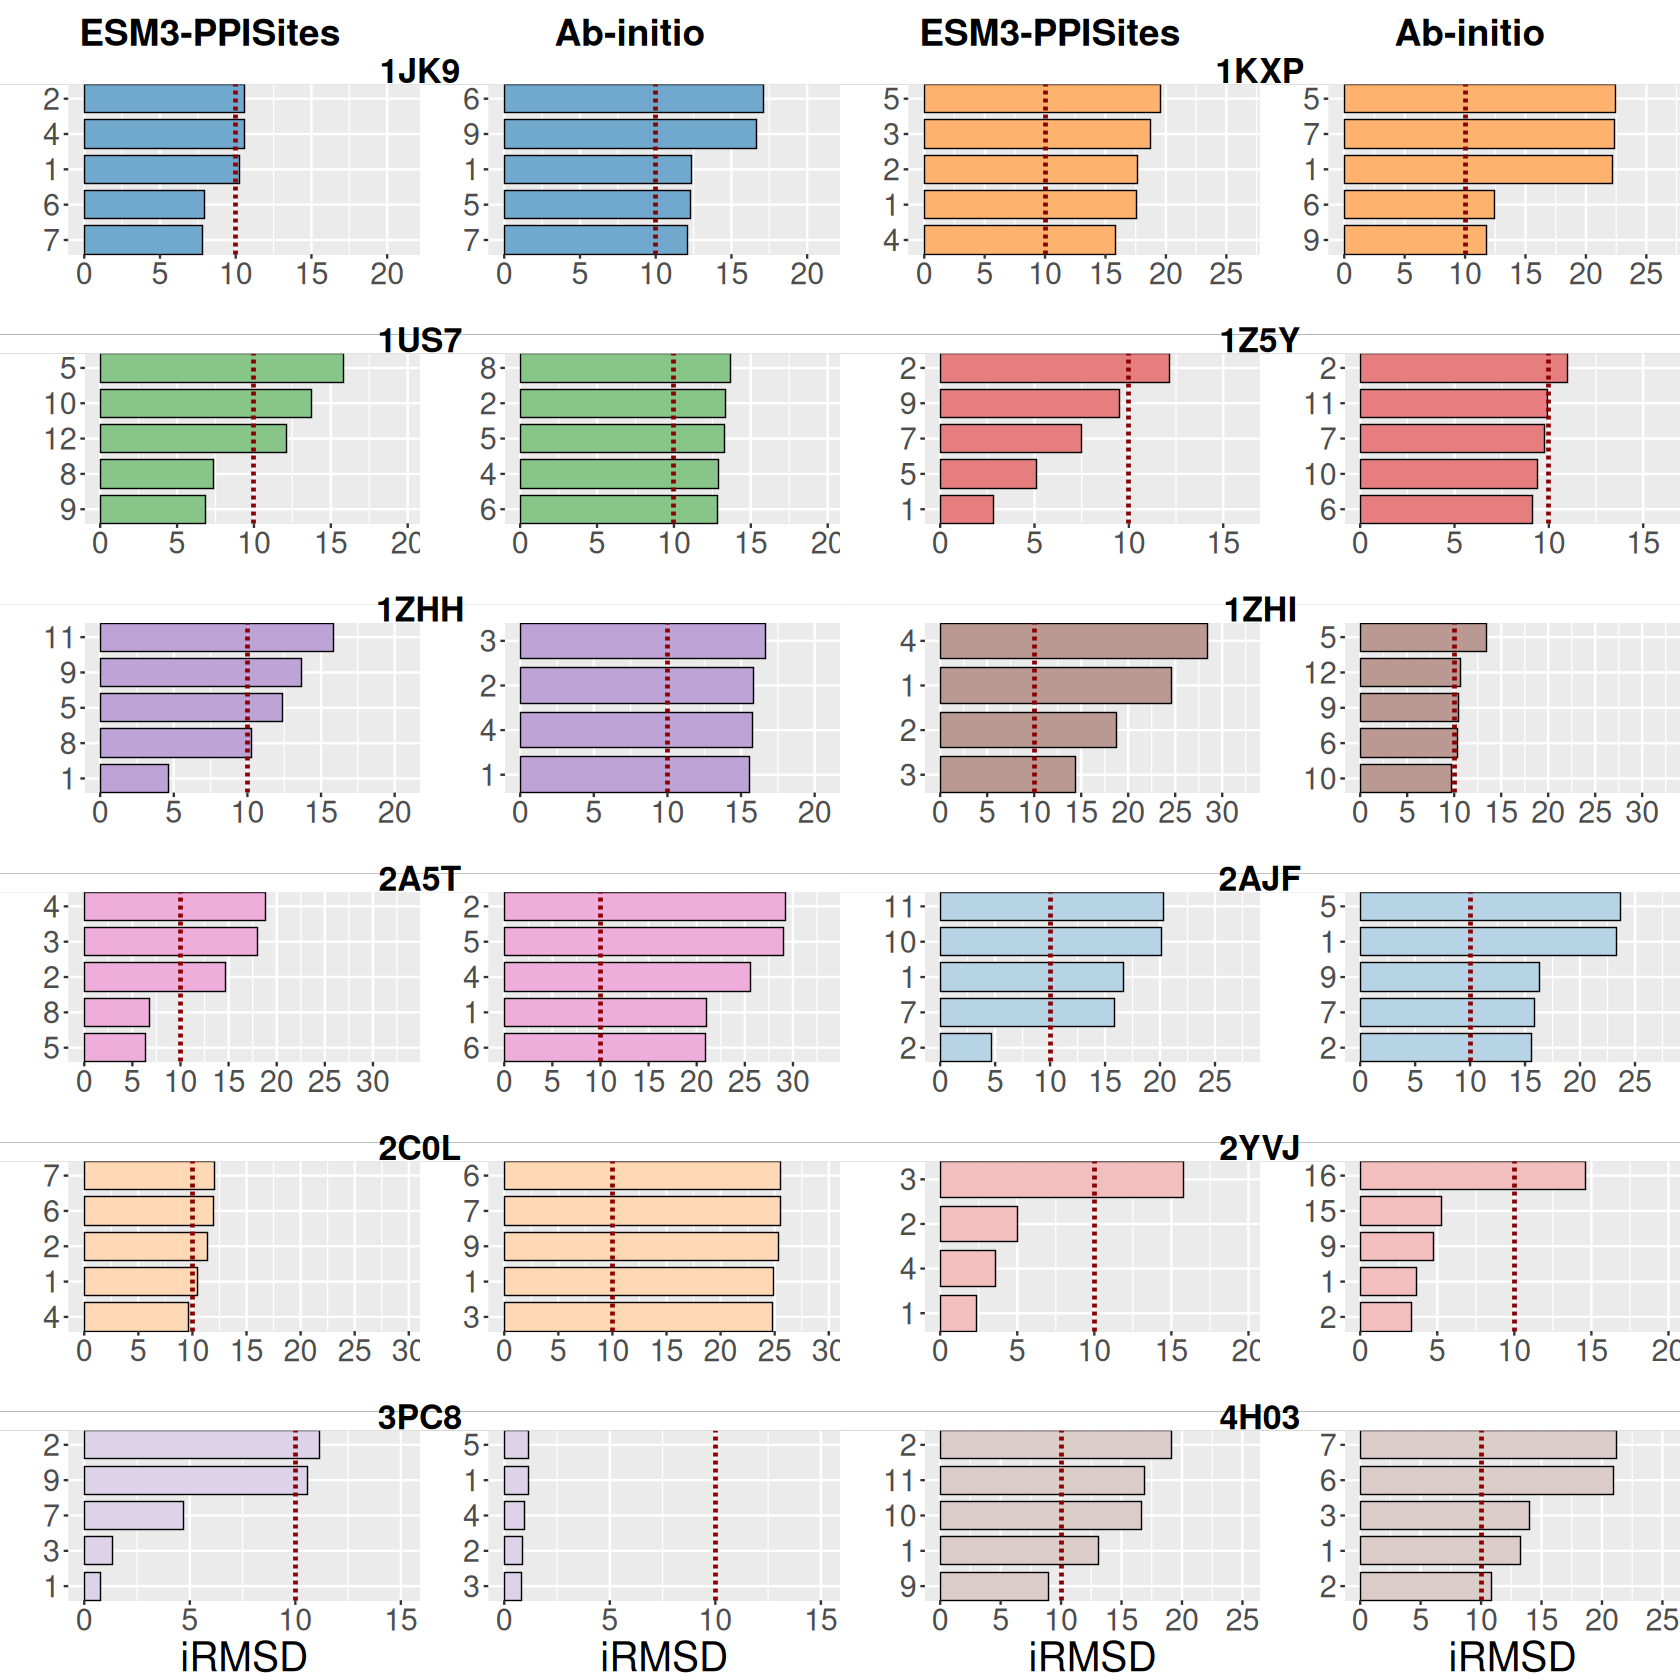

In [9]:
library(cowplot)
library(ggplot2)
library(dplyr)

top_n = 5
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
bar_panels = list()
bar_width = 0.8

for(my_complex in complexes){
    
    df = res_abinitio %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    p_bars_abinitio = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") +
        ggtitle(my_complex)
    max_abinitio = max(df$irmsd)
    
    df = res_eval %>%
        filter(complex == my_complex) %>%
        arrange(irmsd) %>% head(top_n) %>% 
        mutate(y = paste0(complex, "_", score_rank))
    
    max_eval = max(df$irmsd)
    p_bars_eval = ggplot() +
        geom_col(data = df, color = "black", linewidth = 0.3, width = bar_width, aes(
            y = reorder(as.integer(score_rank), irmsd), x = irmsd, fill = complex)) +
        labs(x = "iRMSD", y = "") 
    max_both = max(max_abinitio, max_eval)
    
    bplot_list = list(p_bars_eval, p_bars_abinitio)
    bplot_list = lapply(bplot_list, function(myp){
        myp +
            geom_vline(xintercept = 10, linetype = "dashed", linewidth = 1, color = "darkred") +
            scale_x_continuous(limits = c(0, max_both + 4), breaks = seq(0, 30, by = 5)) +
            scale_y_discrete(expand = expansion(add = c(0.2, 0.2))) +
            scale_fill_manual(values = permanent_palette) +
            theme(legend.position = "none",
                  plot.title = element_text(hjust = 2, size = 20, face = "bold"), 
                  axis.title = element_text(size = 24),           # BIGGER axis titles
                  axis.text = element_text(size = 18),              # BIGGER axis text
                  strip.text = element_text(size = 16))
    })
    bar_panels[[my_complex]] = bplot_list 
}

bar_panels = unlist(bar_panels, recursive = FALSE)

for(i in seq_along(bar_panels)){
    if(i %% 2 != 1) {
        bar_panels[[i]] = bar_panels[[i]] + labs(y = "")
    }
    if(i < length(bar_panels) - 3){
        bar_panels[[i]] = bar_panels[[i]] + labs(x = "")
    }
    bar_panels[[i]] = bar_panels[[i]] + 
        theme(plot.margin = margin(t = 0, r = 0, b = 0, l = 0, unit = "pt"))
}

# ---- 4-COLUMN LAYOUT: TWO COUPLES SIDE BY SIDE ----

# Remove individual plot titles
for(i in seq_along(bar_panels)){
    bar_panels[[i]] = bar_panels[[i]] + ggtitle(NULL)
}

# Build "couples": each couple = one complex with eval + abinitio (2 columns)
# Then place two couples side by side (4 columns total)
# Complexes per row: 2 couples = 4 plots wide
complexes_per_row = 2
n_rows = ceiling(length(complexes) / complexes_per_row)

all_rows = list()

for(r in seq_len(n_rows)){
    
    couple_plots = list()
    couple_titles = list()
    
    for(c in 1:complexes_per_row){
        idx_complex = (r - 1) * complexes_per_row + c
        if(idx_complex > length(complexes)) break
        
        comp = complexes[idx_complex]
        idx1 = 2 * idx_complex - 1   # eval plot
        idx2 = 2 * idx_complex       # abinitio plot
        
        # Single couple: eval + abinitio side by side
        couple = plot_grid(bar_panels[[idx1]], bar_panels[[idx2]],
                           ncol = 2, align = "hv", axis = "tblr",
                           rel_widths = c(1, 1))
        
        # Add a border/frame around each couple
        couple = couple + theme(plot.background = element_rect(color = "black", linewidth = 1, fill = NA))
        
        # Complex name above the couple
        couple_title = ggdraw() + 
            draw_label(comp, size = 20, fontface = "bold", x = 0.5, y = 0.7)
        
        couple_with_title = plot_grid(couple_title, couple,
                                      ncol = 1, rel_heights = c(0.08, 1),
                                      greedy = FALSE)
        
        couple_plots[[c]] = couple_with_title
        couple_titles[[c]] = comp
    }
    
    # Assemble the two couples side by side (4 columns total)
    if(length(couple_plots) == 2){
        row_plot = plot_grid(couple_plots[[1]], couple_plots[[2]],
                             ncol = 2, rel_widths = c(1, 1), greedy = FALSE)
    } else {
        row_plot = couple_plots[[1]]
    }
    
    all_rows[[r]] = row_plot
}

# Column headers: 4 columns = ESM3-PPISites | Ab-initio | ESM3-PPISites | Ab-initio
col_header = plot_grid(
    ggdraw() + draw_label("ESM3-PPISites", size = 22, fontface = "bold", x = 0.5, y = 0.5),
    ggdraw() + draw_label("Ab-initio", size = 22, fontface = "bold", x = 0.5, y = 0.5),
    ggdraw() + draw_label("ESM3-PPISites", size = 22, fontface = "bold", x = 0.5, y = 0.5),
    ggdraw() + draw_label("Ab-initio", size = 22, fontface = "bold", x = 0.5, y = 0.5),
    ncol = 4, rel_widths = c(1, 1, 1, 1)
)

# Assemble everything
final_plot = plot_grid(col_header, plot_grid(plotlist = all_rows, ncol = 1, greedy = FALSE),
                       ncol = 1, rel_heights = c(0.04, 1), greedy = FALSE)

# Wider figure to accommodate 4 columns
options(repr.plot.height = 14, repr.plot.width = 14)
print(final_plot)
ggsave(final_plot, file="PPI_plots/ESM3-PPISites_vs_Ab-initio_4cols.png", height=14, width=14)

In [10]:
# Combined plot for all complexes
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2GAF','2YVJ','3PC8','4H03')
#complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2YVJ','3PC8','4H03')
topres = 10

# Prepare data from all three sources for ALL complexes at once
df_oracle = res_oracle %>%
    filter(complex %in% complexes, score_rank <= topres) %>%
    mutate(method = "Oracle") %>%
    select(score_rank, irmsd, method, complex)

df_abinitio = res_abinitio %>%
    filter(complex %in% complexes, score_rank <= topres) %>%
    mutate(method = "Ab initio") %>%
    select(score_rank, irmsd, method, complex)

df_eval = res_eval %>%
    filter(complex %in% complexes, score_rank <= topres) %>%
    mutate(method = "Evaluation") %>%
    select(score_rank, irmsd, method, complex)

# Combine all data
df_combined = bind_rows(df_oracle, df_abinitio, df_eval)
head(df_combined)

df_wide = df_combined%>%
    mutate(method=gsub(" ", "_", method))%>%
    pivot_wider(names_from=method, values_from=irmsd)%>%
    filter(!is.na(Evaluation))%>%
    pivot_longer(cols=c("Oracle","Ab_initio","Evaluation"), 
        values_to = "irmsd", names_to="method")%>%
    mutate(method=gsub("_"," ",method))
    #%>%
    #filter(!is.na(irmsd))

head(df_wide)

# Sort so lowest irmsd values are drawn first (appear in back)
df_combined = df_wide %>% arrange(desc(irmsd))
#df_combined$score_rank

,score_rank,irmsd,method,complex
,<dbl>,<dbl>,<chr>,<chr>
1,1,2.817,Oracle,1JK9
2,2,2.683,Oracle,1JK9
3,3,2.756,Oracle,1JK9
4,4,2.672,Oracle,1JK9
5,5,2.779,Oracle,1JK9
6,6,2.842,Oracle,1JK9


score_rank,complex,method,irmsd
<dbl>,<chr>,<chr>,<dbl>
1,1JK9,Oracle,2.817
1,1JK9,Ab initio,12.339
1,1JK9,Evaluation,10.257
2,1JK9,Oracle,2.683
2,1JK9,Ab initio,18.756
2,1JK9,Evaluation,10.584


In [11]:
plot_irmsd_comparison <- function(
    df,
    title = "",
    y_label = "iRMSD (Å)",
    x_label = "Score Rank",
    fill_label = "Method",
    fill_colors = c("Oracle" = "#468f6f", "Ab initio" = "#d97645", "Evaluation" = "#835da6"),
    y_limit = c(0, 35),
    y_breaks = seq(0, 30, by = 5),
    ###x_breaks = 1:5,
    hline_y = 10,
    legend_position = "right"
) {
  
  # Extract the title from the 'complex' column if title is empty
  plot_title <- if(title == "") unique(df$complex) else title

  p <- ggplot(df) +
    geom_col(
      aes(x = score_rank, y = irmsd, fill = method),
      color = "black",
      linewidth = 0.3,
      position = "dodge" ### "identity"
    ) +
    geom_hline(
      yintercept = hline_y,
      linetype = "dashed",
      color = "black"
    ) +
    labs(
      title = plot_title,
      y = y_label,
      x = x_label,
      fill = fill_label
    ) +
    scale_y_continuous(
      limits = y_limit,
      breaks = y_breaks
    ) +
    # Force 1:5 breaks and set limits to ensure all ticks show up
    scale_x_continuous(
      #breaks = x_breaks,
      #limits = c(0.5, 5.5),
      #expand = c(0, 0) 
    ) +
    scale_fill_manual(
      values = fill_colors
    ) +
    theme_bw() +
    theme(
      legend.position = legend_position,
      legend.text = element_text(size = 14),
      legend.title = element_text(size = 16, face = "bold"),
      legend.key.size = unit(1, "cm"),
      legend.spacing.y = unit(0.5, "cm"),
      plot.title = element_text(hjust = 0.5, size = 12, face = "bold"), # Smaller title for grid
      axis.title = element_text(size = 10, face = "bold"),
      axis.text = element_text(size = 9),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )
  
  # return(invisible(p)) ensures lapply won't auto-print
  return(invisible(p))
}


############ SECOND VERSION
plot_irmsd_comparison <- function(
    df,
    title = "",
    y_label = "iRMSD (Å)",
    x_label = "Score Rank",
    fill_label = "Method",
    fill_colors = c("Oracle" = "#468f6f", "Ab initio" = "#d97645", "Evaluation" = "#835da6"),
    y_limit = c(0, 50),
    y_breaks = seq(0, 50, by = 5),
    hline_y = 10,
    legend_position = "right"
) {
  
  library(dplyr)
  
  # Extract the title from the 'complex' column if title is empty
  plot_title <- if(title == "") unique(df$complex) else title
  
  # Identify the method with minimum iRMSD for each score_rank
  df_min <- df %>%
    group_by(score_rank) %>%
    slice_min(irmsd, n = 1) %>%
    ungroup() %>%
    mutate(is_min = TRUE)
  
  # Merge back to main dataframe
  df <- df %>%
    left_join(df_min %>% select(score_rank, method, is_min), by = c("score_rank", "method")) %>%
    mutate(
      is_min = ifelse(is.na(is_min), FALSE, is_min),
      border_color = "black", #ifelse(is_min, "red", "black"),
      border_size = ifelse(is_min, 1, 0.1)  # Thick border for min, thin for others
    )
  
  p <- ggplot(df) +
    geom_col(
      aes(x = score_rank, y = irmsd, fill = method, color = border_color, linewidth = border_size),
      position = "dodge"
    ) +
    # Override the color/linewidth scales so they aren't in the legend
    scale_color_identity() +
    scale_linewidth_identity() +
    geom_hline(
      yintercept = hline_y,
      linetype = "dashed",
      color = "black"
    ) +
    labs(
      title = plot_title,
      y = y_label,
      x = x_label,
      fill = fill_label
    ) +
    scale_y_continuous(
      limits = y_limit,
      breaks = y_breaks
    ) +
    scale_x_continuous() +
    scale_fill_manual(
      values = fill_colors
    ) +
    theme_bw() +
    theme(
      legend.position = legend_position,
      legend.text = element_text(size = 14),
      legend.title = element_text(size = 16, face = "bold"),
      legend.key.size = unit(1, "cm"),
      legend.spacing.y = unit(0.5, "cm"),
      plot.title = element_text(hjust = 0.5, size = 12, face = "bold"),
      axis.title = element_text(size = 10, face = "bold"),
      axis.text = element_text(size = 9),
      panel.grid.minor = element_blank(),
      panel.grid.major.x = element_blank()
    )
  
  return(invisible(p))
}

In [12]:
decompose <- function(lines) {
  pattern       <- "=== Processing:"
  match_indices <- grep(pattern, lines)
  
  if (length(match_indices) == 0) {
    return(list(lines))
  }
  
  breakpoints <- c(match_indices, length(lines) + 1)
  
  result <- list()
  nomi   <- character()
  
  for (i in seq_len(length(breakpoints) - 1)) {
    start <- breakpoints[i]
    end   <- breakpoints[i + 1] - 1
    
    block    <- lines[start:end]
    run_name <- sub(".*=== Processing: (\\S+) .*", "\\1", lines[start])
    
    result[[length(result) + 1]] <- block
    nomi <- c(nomi, run_name)
  }
  
  names(result) <- nomi
  return(result)
}


decompose_eval <- function(lines) {
  # Pattern matches: data/haddock_units/XXXX/configs/patches_X_X_X.cfg
  pattern       <- "^data/haddock_units/[^/]+/configs/patches_[0-9]+_[0-9]+_[0-9]+\\.cfg$"
  match_indices <- grep(pattern, lines)
  
  if (length(match_indices) == 0) {
    return(list(lines))
  }
  
  breakpoints <- c(match_indices, length(lines) + 1)
  
  result <- list()
  nomi   <- character()
  
  for (i in seq_len(length(breakpoints) - 1)) {
    start <- breakpoints[i]
    end   <- breakpoints[i + 1] - 1
    
    block    <- lines[start:end]
    # Extract run name: e.g., "1JK9/patches_0_0_0" from the config path
    run_name <- sub(".*data/haddock_units/([^/]+)/configs/(patches_[0-9]+_[0-9]+_[0-9]+)\\.cfg.*", 
                    "\\1/\\2", lines[start])
    
    result[[length(result) + 1]] <- block
    nomi <- c(nomi, run_name)
  }
  
  names(result) <- nomi
  return(result)
}

In [13]:
log_file_abinitio = readLines("logs_abinitio/log_abinitio_10k_haddock_1216060.out")

log_list = decompose(lines=log_file_abinitio)
#log_list[[1]]

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  # job start from header line
  job_start <- as.POSIXct(
    sub(".*Started: ([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}) .*", "\\1", x[1]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  # extract module name and end timestamp from each line
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_abinitio = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='abinitio')

head(data_abinitio)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9,topoaa,2026-05-21 12:08:08,2026-05-21 12:08:16,8,abinitio
2,1JK9,rigidbody,2026-05-21 12:08:16,2026-05-21 12:20:42,746,abinitio
3,1JK9,seletop,2026-05-21 12:20:42,2026-05-21 12:20:43,1,abinitio
4,1JK9,flexref,2026-05-21 12:20:43,2026-05-21 12:22:56,133,abinitio
5,1JK9,emref,2026-05-21 12:22:56,2026-05-21 12:23:08,12,abinitio
6,1JK9,clustfcc,2026-05-21 12:23:08,2026-05-21 12:23:09,1,abinitio


In [14]:
log_file_oracle = readLines("logs_oracle/log_oracle_rig100_top10_haddock_1231572.out")

log_list = decompose(lines=log_file_oracle)

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  # job start from header line
  job_start <- as.POSIXct(
    sub(".*Started: ([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}) .*", "\\1", x[1]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  # extract module name and end timestamp from each line
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_oracle = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='oracle')

head(data_oracle)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9,topoaa,2026-05-25 09:30:42,2026-05-25 09:30:48,6,oracle
2,1JK9,rigidbody,2026-05-25 09:30:48,2026-05-25 09:30:57,9,oracle
3,1JK9,seletop,2026-05-25 09:30:57,2026-05-25 09:30:57,0,oracle
4,1JK9,flexref,2026-05-25 09:30:57,2026-05-25 09:31:29,32,oracle
5,1JK9,emref,2026-05-25 09:31:29,2026-05-25 09:31:32,3,oracle
6,1JK9,clustfcc,2026-05-25 09:31:32,2026-05-25 09:31:32,0,oracle


In [15]:
log_file_eval = readLines("logs_eval/log_eval_1236542.out")
log_list = decompose_eval(lines=log_file_eval)

parsed_logs <- lapply(names(log_list), function(jobname) {
  x <- log_list[[jobname]]
  
  # Extract all timestamps from the block
  all_timestamps <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", 
        x[grepl("\\[20[0-9]{2}-[0-9]{2}-[0-9]{2}", x)]),
    format = "%Y-%m-%d %H:%M:%S"
  )
  job_start <- min(all_timestamps, na.rm = TRUE)
  
  # Lines where modules finish
  module_lines <- x[grepl("Module .+ finished", x)]
  modules <- sub(".*Module \\[(.+)\\] finished.*", "\\1", module_lines)
  ends    <- as.POSIXct(
    sub("\\[([0-9]{4}-[0-9]{2}-[0-9]{2} [0-9]{2}:[0-9]{2}:[0-9]{2}).*", "\\1", module_lines),
    format = "%Y-%m-%d %H:%M:%S"
  )
  
  # start of each module = job_start for the first, end of previous for the rest
  starts <- c(job_start, ends[-length(ends)])
  
  data.frame(
    jobname  = jobname,
    module   = modules,
    start    = starts,
    end      = ends,
    duration = as.numeric(difftime(ends, starts, units = "secs")),
    stringsAsFactors = FALSE
  )
})
#parsed_logs[[1]]
data_eval = data.frame(do.call(rbind, parsed_logs))%>%
    mutate(runtype='ESM3-PPISites')

head(data_eval)

,jobname,module,start,end,duration,runtype
,<chr>,<chr>,<dttm>,<dttm>,<dbl>,<chr>
1,1JK9/patches_0_0_0,topoaa,2026-05-25 17:31:49,2026-05-25 17:31:56,7,ESM3-PPISites
2,1JK9/patches_0_0_0,rigidbody,2026-05-25 17:31:56,2026-05-25 17:32:06,10,ESM3-PPISites
3,1JK9/patches_0_0_0,seletop,2026-05-25 17:32:06,2026-05-25 17:32:06,0,ESM3-PPISites
4,1JK9/patches_0_0_0,emref,2026-05-25 17:32:06,2026-05-25 17:32:11,5,ESM3-PPISites
5,1JK9/patches_0_0_0,caprieval,2026-05-25 17:32:11,2026-05-25 17:32:12,1,ESM3-PPISites
6,1JK9/patches_0_0_1,topoaa,2026-05-25 17:32:40,2026-05-25 17:32:44,4,ESM3-PPISites


In [16]:
data_all = rbind(data_oracle, data_eval, data_abinitio)%>%
    mutate(copy_jobname = jobname)%>%
    mutate(jobname = gsub("/.+$","",jobname))%>%
    group_by(jobname, runtype)%>%
    summarize(minutes = ceiling(sum(duration)/60), .groups="drop")
head(data_all)


jobname,runtype,minutes
<chr>,<chr>,<dbl>
1JK9,ESM3-PPISites,4
1JK9,abinitio,16
1JK9,oracle,1
1KXP,ESM3-PPISites,6
1KXP,abinitio,38
1KXP,oracle,3


In [17]:
complexes = c('1JK9','1KXP','1US7','1Z5Y','1ZHH','1ZHI','2A5T','2AJF','2C0L','2GAF','2YVJ','3PC8','4H03')

hex_colors <- c("#70A8CE", "#FFB26E", "#88C588", "#E67D7E", "#BDA3D6", "#BA9993", "#EEADDA")
hex_light2 <- colorRampPalette(c("white", "white"))(7)  # placeholder
hex_light2 <- sapply(hex_colors, function(c) colorRampPalette(c(c, "#FFFFFF"))(3)[2])

permanent_palette = c(hex_colors, hex_light2)
names(permanent_palette) = complexes
permanent_palette = permanent_palette[complexes]
permanent_palette

1JK9      1KXP      1US7      1Z5Y      1ZHH      1ZHI      2A5T      2AJF 
"#70A8CE" "#FFB26E" "#88C588" "#E67D7E" "#BDA3D6" "#BA9993" "#EEADDA" "#B7D3E6" 
     2C0L      2GAF      2YVJ      3PC8      4H03 
"#FFD8B6" "#C3E2C3" "#F2BEBE" "#DED1EA" "#DCCCC9"


Attaching package: ‘scales’


The following object is masked from ‘package:readr’:

    col_factor




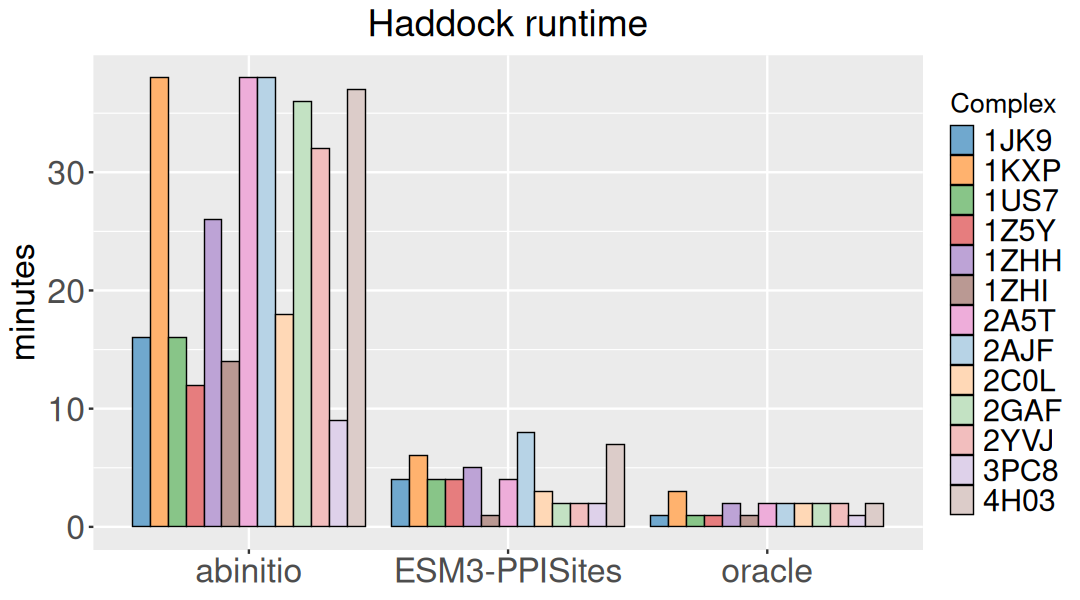

In [18]:
library(ggplot2)
library(scales)

options(repr.plot.height=5, repr.plot.width=8)

p_timing = ggplot() +
    geom_col(data=data_all, color = "black", linewidth = 0.3, position = "dodge",
             aes(x=runtype, y=minutes, group=jobname, fill=jobname)) +
    scale_fill_manual(values=permanent_palette) +
    ggtitle("Haddock runtime") +
    labs(x = NULL, fill = "Complex") + # Removes x title, changes legend title
    theme(
          plot.title = element_text(hjust = 0.5, size = 22),
          axis.title = element_text(size = 20),       
          axis.text = element_text(size = 20),                  
          strip.text = element_text(size = 16)) +
    theme(
        legend.position = "right",
        legend.title = element_text(size = 16),       # Un-commented if you want to style it
        legend.text = element_text(size = 18),        # bigger labels
        legend.key.size = unit(0.5, "cm"),            # bigger color keys
        legend.spacing.y = unit(0.5, "cm")            # more vertical spacing
    )

outdir = "PPI_plots"
#ggsave(filename=file.path(outdir, "haddock_runtime.png"), width=7, height=5)

options(repr.plot.height=5, repr.plot.width=9)
p_timing

In [19]:
outdir = "PPI_plots"
dir.create("PPI_plots", showWarnings=FALSE)
ggsave(filename=file.path(outdir, "haddock_runtime.png"), width=9, height=5)